In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from joblib import dump, load

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.calibration import calibration_curve
import shap

In [16]:
# Load training data
#with open('train_data.pkl', 'rb') as f:
#    X_train, y_train = pickle.load(f)

# Load testing data
with open('test_data.pkl', 'rb') as f:
    X_test, y_test = pickle.load(f)

In [17]:
order_ids = X_test['OrderItemId']
X_test.drop('OrderItemId', axis=1, inplace=True)

In [18]:
# Define the list of model filenames
model_filenames = {
    #'Logistic Regression': 'Models/Logistic Regression_model.joblib',
    #'Decision Tree': 'Models/Decision Tree_model.joblib',
    'Random Forest': 'Models/Random Forest_model.joblib',
    #'Gradient Boosting': 'Models/Gradient Boosting_model.joblib',
    #'XGBoost': 'Models/XGBoost_model.joblib',
    #'K-Nearest Neighbors': 'Models/K-Nearest Neighbors_model.joblib',
    #'Neural Network': 'Models/Neural Network_model.joblib'
}

In [19]:
# Load all models into a dictionary
loaded_models = {}
for name, filename in model_filenames.items():
    loaded_models[name] = load(filename)
    print(loaded_models[name])

RandomForestClassifier(class_weight='balanced', max_depth=35,
                       max_features=np.float64(0.9745339839624769),
                       n_estimators=355, random_state=42)


Evaluating Random Forest...


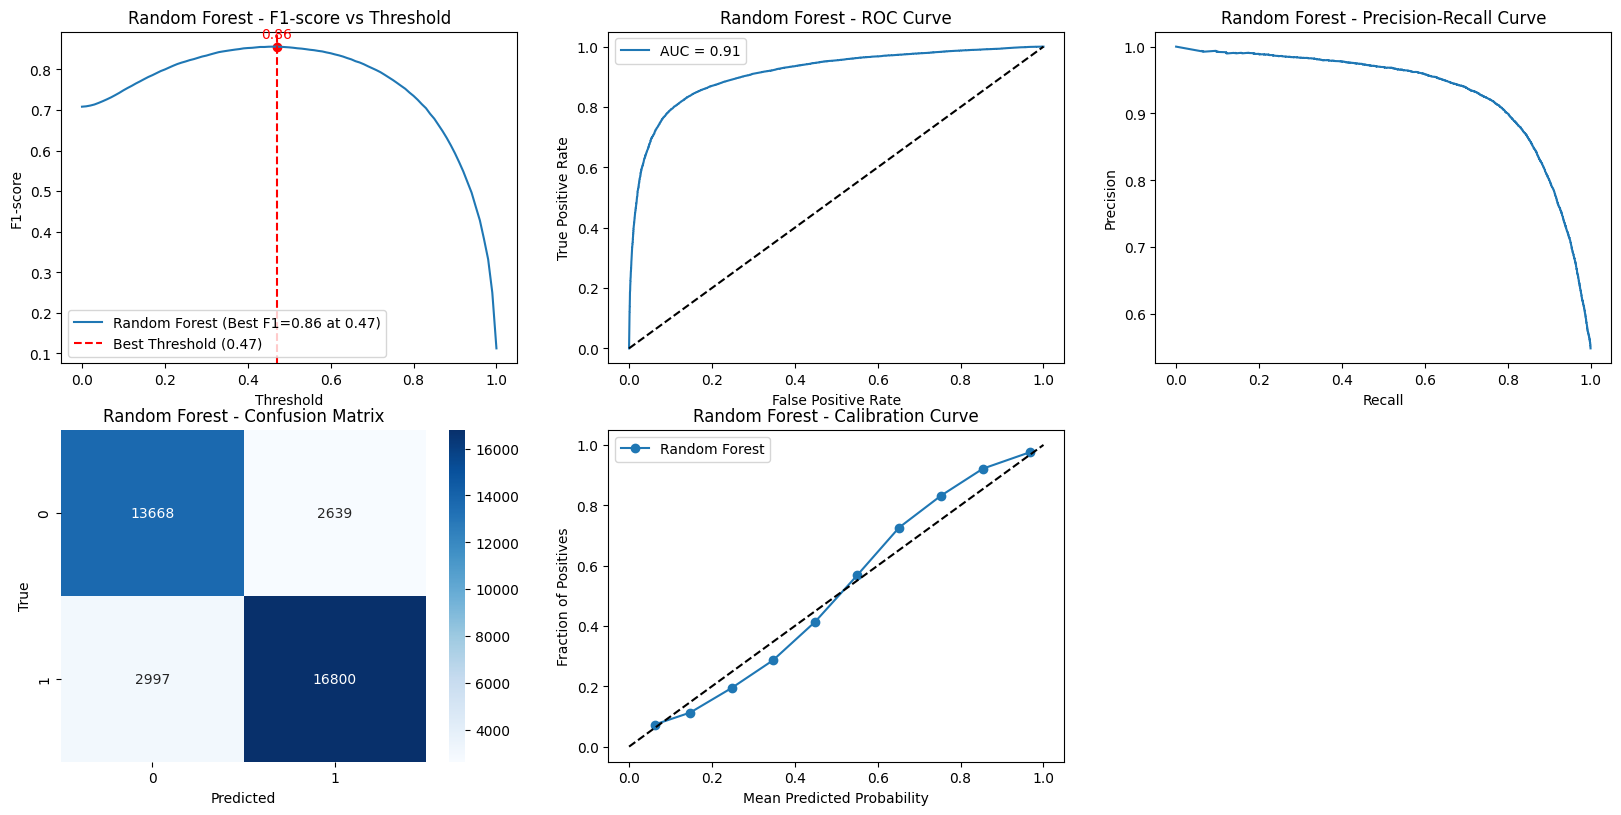

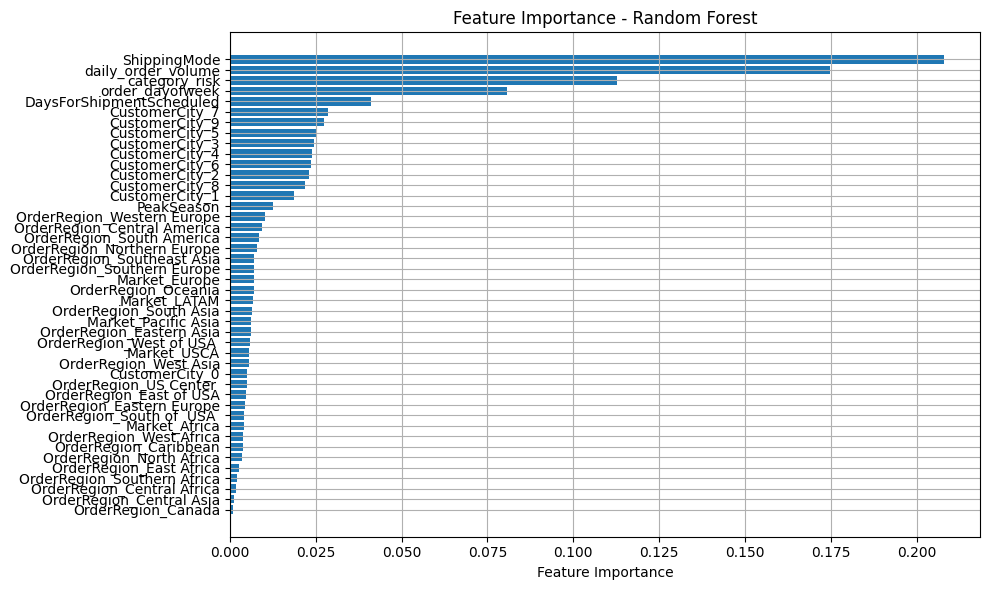

In [20]:
# evaluation matrix
# Evaluate each model on the test set
model_predict = {}
# Store metrics for summary plots
model_metrics = {}

#threshhold = 0.5

# Create plots
plt.figure(figsize=(20, 25))
plot_index = 1

for name, model in loaded_models.items():
  print(f"Evaluating {name}...")
  # Predict on the test set
  #y_pred = model.predict(X_test)
  # Get predicted probabilities
  y_prob = model.predict_proba(X_test)[:, 1]

  # Now we find out the best threshold based on f1-score
  thresholds_lst = np.arange(0.0, 1.01, 0.01)
  f1_scores = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds_lst]

  best_idx = np.argmax(f1_scores)
  best_thresh = thresholds_lst[best_idx]
  best_f1 = f1_scores[best_idx]

  #print(f"Best threshold: {best_thresh}, Best F1-score: {best_f1}")

  # Convert probabilities to class labels (default threshold = 0.5)
  y_pred = (y_prob >= best_thresh).astype(int)

  # Store predictions
  model_predict[name] = {}
  model_predict[name]['order_item_id'] = order_ids
  model_predict[name]['prediction'] = y_pred

  # Metrics
  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred) # f1 score for class 1, by default
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)

  model_metrics[name] = {
      'Accuracy': acc,
      'F1': f1,
      'Precision': precision,
      'Recall': recall,
      'Best Threshold': best_thresh
      }

  # Plot F1-score vs Threshold
  plt.subplot(5, 3, plot_index)
  plt.plot(thresholds_lst, f1_scores, label=f'{name} (Best F1={best_f1:.2f} at {best_thresh:.2f})')
  plt.axvline(x=best_thresh, color='red', linestyle='--', label=f'Best Threshold ({best_thresh:.2f})')

  # Annotate points on curve
  plt.scatter([best_thresh], [best_f1], color='red')
  plt.text(best_thresh, best_f1 + 0.02, f'{best_f1:.2f}', ha='center', color='red')

  plt.title(f'{name} - F1-score vs Threshold')
  plt.xlabel('Threshold')
  plt.ylabel('F1-score')
  plt.legend()
  plot_index += 1

  # ROC Curve
  fpr, tpr, _ = roc_curve(y_test, y_prob)
  roc_auc = auc(fpr, tpr)

  plt.subplot(5, 3, plot_index)
  plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
  plt.plot([0, 1], [0, 1], 'k--')
  plt.title(f'{name} - ROC Curve')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.legend()
  plot_index += 1

  # Precision-Recall Curve
  precision, recall, _ = precision_recall_curve(y_test, y_prob)
  plt.subplot(5, 3, plot_index)
  plt.plot(recall, precision)
  plt.title(f'{name} - Precision-Recall Curve')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plot_index += 1

  # Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)
  plt.subplot(5, 3, plot_index)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(f'{name} - Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plot_index += 1

  # Calibration Curve
  plt.subplot(5, 3, plot_index)
  prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
  plt.plot(prob_pred, prob_true, marker='o', label=name)
  plt.plot([0, 1], [0, 1], 'k--') # plots the diagonal reference line — a dashed black line that represents a perfectly calibrated model.
  plt.title(f'{name} - Calibration Curve')
  plt.xlabel('Mean Predicted Probability')
  plt.ylabel('Fraction of Positives')
  plt.legend()
  plot_index += 1

  # Feature Importance
  feature_importance = model.feature_importances_
  feature_names = X_test.columns

  # Zip and sort
  sorted_features = sorted(zip(feature_names, feature_importance), key=lambda x: x[1], reverse=False)

  # Unzip for plotting
  features, scores = zip(*sorted_features)

  # Plot
  plt.figure(figsize=(10, 6))
  plt.barh(features, scores)
  plt.xlabel("Feature Importance")
  plt.title("Feature Importance - Random Forest")

plt.grid(True)
plt.tight_layout()
plt.show()

Now we are creating a dataframe that contains y_test and best model's predicted values.

In [21]:
for name in loaded_models.keys():
  results_df = pd.DataFrame({
    "OrderItemId": model_predict[name]["order_item_id"].reset_index(drop=True),
    "Prediction": model_predict[name]["prediction"]
  })
  results_df.to_csv(f"{name}_predictions.csv", index=False)